# Notebook Objective

# 06 Explainability with SHAP

This notebook explains the best-performing RUL prediction model using SHAP values.

The main objectives are:

- recreate the preprocessing and feature engineering workflow
- retrain or load the selected best model
- compute SHAP values for validation or test samples
- identify globally important engineered window features
- explain individual RUL predictions
- analyze how feature contributions change across engine lifetime
- connect model explanations back to degradation-relevant sensor behavior

This notebook focuses on interpretability and does not introduce new model training experiments.

# Imports and Project Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from src.data_loading import DATASET_IDS
from src.config import load_config, flatten_config
from src.pipeline import recreate_prediction_pipeline
from src.models import build_xgboost_model


# Load and Recreate Feature Pipeline

The selected C-MAPSS subset is loaded, preprocessed and transformed into tabular window features using the same workflow as in the previous notebooks. This ensures that the explainability analysis is reproducible and does not depend on variables from another notebook session.

In [3]:
config = load_config()
flat_config = flatten_config(config)

CURRENT_DATASET = flat_config["CURRENT_DATASET"]
RUL_CAP = flat_config["RUL_CAP"]
VALIDATION_SIZE = flat_config["VALIDATION_SIZE"]
RANDOM_STATE = flat_config["RANDOM_STATE"]
WINDOW_SIZE = flat_config["WINDOW_SIZE"]
WINDOW_STEP = flat_config["WINDOW_STEP"]

index_cols = flat_config["INDEX_COLS"]
target_cols = flat_config["TARGET_COLS"]
helper_cols = flat_config["HELPER_COLS"]
target_col = flat_config["TARGET_COL"]

model_config = config["models"]
conformal_config = config["conformal"]
simulation_config = config["simulation"]

if CURRENT_DATASET not in DATASET_IDS:
    raise ValueError(f"Unknown dataset: {CURRENT_DATASET}")


In [4]:
# Recreate the configured preprocessing and feature engineering pipeline.
pipeline_outputs = recreate_prediction_pipeline(config)
globals().update(pipeline_outputs)


In [5]:
print(f"Current dataset: {CURRENT_DATASET}")
print(f"Input features before window aggregation: {len(feature_cols)}")
print(f"Tabular window features: {len(tabular_feature_cols)}")

print(f"X_train_tabular shape: {X_train_tabular.shape}")
print(f"y_train_tabular shape: {y_train_tabular.shape}")

print(f"X_val_tabular shape:   {X_val_tabular.shape}")
print(f"y_val_tabular shape:   {y_val_tabular.shape}")

print(f"X_test_tabular shape:  {X_test_tabular.shape}")

Current dataset: FD001
Input features before window aggregation: 17
Tabular window features: 102
X_train_tabular shape: (14241, 102)
y_train_tabular shape: (14241,)
X_val_tabular shape:   (3490, 102)
y_val_tabular shape:   (3490,)
X_test_tabular shape:  (10196, 102)


In [6]:
# Ensure that every tabular training sample has one target value.
assert X_train_tabular.shape[0] == y_train_tabular.shape[0]

# Ensure that every tabular validation sample has one target value.
assert X_val_tabular.shape[0] == y_val_tabular.shape[0]

# Ensure that train, validation and test use identical tabular feature columns.
assert list(X_train_tabular.columns) == list(X_val_tabular.columns)
assert list(X_train_tabular.columns) == list(X_test_tabular.columns)

# Ensure that train and validation are split by disjoint engine units.
assert set(train_engines).isdisjoint(set(val_engines))

# Train Selected Model for Explainability

XGBoost is recreated using the same hyperparameters as in Notebook 05. It is used as the primary explainability model because it achieved the strongest official test performance while remaining suitable for tree-based SHAP analysis.


In [7]:
xgb_model = build_xgboost_model(
    model_config,
    random_state=RANDOM_STATE
)

xgb_model.fit(
    X_train_tabular,
    y_train_tabular
)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [8]:
xgb_val_pred = xgb_model.predict(X_val_tabular)

xgb_validation_metrics = {
    "MAE": mean_absolute_error(y_val_tabular, xgb_val_pred),
    "RMSE": root_mean_squared_error(y_val_tabular, xgb_val_pred)
}

xgb_validation_metrics

{'MAE': 9.306013107299805, 'RMSE': 12.669183731079102}

In [9]:
def cmapss_score(y_true, y_pred):
    error = y_pred - y_true
    
    score = np.where(
        error < 0,
        np.exp(-error / 13) - 1,
        np.exp(error / 10) - 1
    )
    
    return np.sum(score)

In [10]:
xgb_validation_metrics["C-MAPSS_score"] = cmapss_score(
    y_val_tabular,
    xgb_val_pred
)

xgb_validation_metrics

{'MAE': 9.306013107299805,
 'RMSE': 12.669183731079102,
 'C-MAPSS_score': np.float64(10083.464274544353)}

In [11]:
# Ensure that the XGBoost model returns one prediction for every validation sample.
assert xgb_val_pred.shape[0] == y_val_tabular.shape[0]

# Ensure that XGBoost validation predictions are finite numeric values.
assert np.isfinite(xgb_val_pred).all()

The XGBoost model is retrained with the same configuration used in Notebook 05. Its validation performance is checked to ensure that the model behaves as expected before SHAP values are computed.

# SHAP Explainer Setup

SHAP values are computed for a representative sample of validation windows. The validation set is used because it was not used for model training and therefore provides a more realistic view of model behavior on unseen engine trajectories.

In [12]:
SHAP_SAMPLE_SIZE = 1000

X_val_shap = X_val_tabular.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_val_tabular)),
    random_state=RANDOM_STATE
)

X_val_shap.head()

,setting_1__mean,setting_1__std,setting_1__min,setting_1__max,setting_1__last,setting_1__slope,setting_2__mean,setting_2__std,setting_2__min,setting_2__max,setting_2__last,setting_2__slope,T24 (LPC outlet temperature)__mean,T24 (LPC outlet temperature)__std,T24 (LPC outlet temperature)__min,T24 (LPC outlet temperature)__max,T24 (LPC outlet temperature)__last,T24 (LPC outlet temperature)__slope,T30 (HPC outlet temperature)__mean,T30 (HPC outlet temperature)__std,T30 (HPC outlet temperature)__min,T30 (HPC outlet temperature)__max,T30 (HPC outlet temperature)__last,T30 (HPC outlet temperature)__slope,T50 (LPT outlet temperature)__mean,T50 (LPT outlet temperature)__std,T50 (LPT outlet temperature)__min,T50 (LPT outlet temperature)__max,T50 (LPT outlet temperature)__last,T50 (LPT outlet temperature)__slope,P15 (bypass duct pressure)__mean,P15 (bypass duct pressure)__std,P15 (bypass duct pressure)__min,P15 (bypass duct pressure)__max,P15 (bypass duct pressure)__last,P15 (bypass duct pressure)__slope,P30 (HPC outlet pressure)__mean,P30 (HPC outlet pressure)__std,P30 (HPC outlet pressure)__min,P30 (HPC outlet pressure)__max,P30 (HPC outlet pressure)__last,P30 (HPC outlet pressure)__slope,Nf (Physical fan speed)__mean,Nf (Physical fan speed)__std,Nf (Physical fan speed)__min,Nf (Physical fan speed)__max,Nf (Physical fan speed)__last,Nf (Physical fan speed)__slope,Nc (Physical core speed)__mean,Nc (Physical core speed)__std,Nc (Physical core speed)__min,Nc (Physical core speed)__max,Nc (Physical core speed)__last,Nc (Physical core speed)__slope,Ps30 (Static pressure at HPC outlet)__mean,Ps30 (Static pressure at HPC outlet)__std,Ps30 (Static pressure at HPC outlet)__min,Ps30 (Static pressure at HPC outlet)__max,Ps30 (Static pressure at HPC outlet)__last,Ps30 (Static pressure at HPC outlet)__slope,phi (Ratio of fuel flow to Ps30)__mean,phi (Ratio of fuel flow to Ps30)__std,phi (Ratio of fuel flow to Ps30)__min,phi (Ratio of fuel flow to Ps30)__max,phi (Ratio of fuel flow to Ps30)__last,phi (Ratio of fuel flow to Ps30)__slope,NRf (Corrected fan speed)__mean,NRf (Corrected fan speed)__std,NRf (Corrected fan speed)__min,NRf (Corrected fan speed)__max,NRf (Corrected fan speed)__last,NRf (Corrected fan speed)__slope,NRc (Corrected core speed)__mean,NRc (Corrected core speed)__std,NRc (Corrected core speed)__min,NRc (Corrected core speed)__max,NRc (Corrected core speed)__last,NRc (Corrected core speed)__slope,BPR (Bypass ratio)__mean,BPR (Bypass ratio)__std,BPR (Bypass ratio)__min,BPR (Bypass ratio)__max,BPR (Bypass ratio)__last,BPR (Bypass ratio)__slope,htBleed (Bleed enthalpy)__mean,htBleed (Bleed enthalpy)__std,htBleed (Bleed enthalpy)__min,htBleed (Bleed enthalpy)__max,htBleed (Bleed enthalpy)__last,htBleed (Bleed enthalpy)__slope,W31 (HPT Cool air flow)__mean,W31 (HPT Cool air flow)__std,W31 (HPT Cool air flow)__min,W31 (HPT Cool air flow)__max,W31 (HPT Cool air flow)__last,W31 (HPT Cool air flow)__slope,W32 (LPT Cool air flow)__mean,W32 (LPT Cool air flow)__std,W32 (LPT Cool air flow)__min,W32 (LPT Cool air flow)__max,W32 (LPT Cool air flow)__last,W32 (LPT Cool air flow)__slope
295,-0.060726,0.771342,-1.685858,1.372677,-0.772862,0.029858,-0.166034,0.932660,-1.715191,1.360341,1.360341,-0.005018,-1.033788,0.674004,-2.725518,0.305945,-1.219824,0.014810,-0.636421,0.593283,-2.019498,0.438916,-0.599665,0.016029,-0.745437,0.440450,-1.561468,0.217605,-0.828646,0.013264,0.13902,2.775558e-17,0.13902,0.13902,0.13902,2.400658e-18,0.971369,0.516776,-0.368048,1.956088,1.409233,-0.021992,-1.154958,0.403253,-2.211887,-0.371699,-0.654805,0.004220,0.468663,0.211773,0.021661,0.879594,0.558310,0.010716,-0.864317,0.365768,-1.616974,-0.262191,-0.939582,0.012039,0.804013,0.318536,0.248887,1.296551,1.133279,-0.005521,-1.155597,0.420150,-2.313093,-0.360690,-1.336891,0.006484,0.592778,0.152625,0.302850,0.942577,0.846082,0.006055,-0.803193,0.506455,-1.789676,0.753851,-0.995157,0.002381,-0.693300,0.741770,-2.719681,0.513906,-0.779529,0.023883,0.578611,0.643802,-0.76

In [13]:
shap_sample_indices = X_val_shap.index

val_shap_metadata = val_window_metadata.loc[
    shap_sample_indices
].reset_index(drop=True)

y_val_shap = y_val_tabular.loc[
    shap_sample_indices
].reset_index(drop=True)

X_val_shap = X_val_shap.reset_index(drop=True)

In [14]:
# Ensure that the SHAP sample, metadata and target values contain the same number of rows.
assert X_val_shap.shape[0] == val_shap_metadata.shape[0] == y_val_shap.shape[0]

# Ensure that the SHAP sample uses the same feature columns as the validation matrix.
assert list(X_val_shap.columns) == list(X_val_tabular.columns)

In [15]:
explainer = shap.TreeExplainer(xgb_model)

In [16]:
shap_values = explainer.shap_values(X_val_shap)

In [17]:
print(f"SHAP sample shape: {X_val_shap.shape}")
print(f"SHAP values shape: {shap_values.shape}")

SHAP sample shape: (1000, 102)
SHAP values shape: (1000, 102)


In [18]:
# Ensure that one SHAP value is computed for each feature of each sampled validation row.
assert shap_values.shape == X_val_shap.shape

In [19]:
explainer.expected_value

np.float32(80.819984)

The SHAP values have the same shape as the sampled validation feature matrix. Each value describes how much a specific engineered feature contributes to increasing or decreasing the predicted RUL for one validation window.

# Global Feature Importance

Global SHAP importance is computed as the mean absolute SHAP value per feature across the sampled validation windows. This indicates which engineered window features have the strongest overall influence on the model predictions.

In [20]:
shap_importance = pd.DataFrame({
    "feature": X_val_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

shap_importance.head(20)

,feature,mean_abs_shap
0,T30 (HPC outlet temperature)__mean,5.834907
1,Ps30 (Static pressure at HPC outlet)__slope,4.936744
2,htBleed (Bleed enthalpy)__mean,4.860750
3,Ps30 (Static pressure at HPC outlet)__max,3.648803
4,phi (Ratio of fuel flow to Ps30)__slope,3.088325
5,T50 (LPT outlet temperature)__slope,2.667413
6,Nc (Physical core speed)__slope,2.406237
7,NRc (Corrected core speed)__slope,2.193835
8,Nf (Physical fan speed)__slope,2.170959
9,NRf (Corrected fan speed)__slope,1.959607


In [21]:
# Seperate sensor and statistic
shap_importance["base_feature"] = (
    shap_importance["feature"]
    .str.split("__")
    .str[0]
)

shap_importance["statistic"] = (
    shap_importance["feature"]
    .str.split("__")
    .str[1]
)

shap_importance.head(20)

,feature,mean_abs_shap,base_feature,statistic
0,T30 (HPC outlet temperature)__mean,5.834907,T30 (HPC outlet temperature),mean
1,Ps30 (Static pressure at HPC outlet)__slope,4.936744,Ps30 (Static pressure at HPC outlet),slope
2,htBleed (Bleed enthalpy)__mean,4.860750,htBleed (Bleed enthalpy),mean
3,Ps30 (Static pressure at HPC outlet)__max,3.648803,Ps30 (Static pressure at HPC outlet),max
4,phi (Ratio of fuel flow to Ps30)__slope,3.088325,phi (Ratio of fuel flow to Ps30),slope
5,T50 (LPT outlet temperature)__slope,2.667413,T50 (LPT outlet temperature),slope
6,Nc (Physical core speed)__slope,2.406237,Nc (Physical core speed),slope
7,NRc (Corrected core speed)__slope,2.193835,NRc (Corrected core speed),slope
8,Nf (Physical fan speed)__slope,2.170959,Nf (Physical fan speed),slope
9,NRf (Corrected fan speed)__slope,1.959607,NRf (Corrected fan speed),slope


In [22]:
# Ensure that one global SHAP importance value exists for every tabular feature.
assert shap_importance.shape[0] == X_val_shap.shape[1]

# Ensure that all SHAP importance values are non-negative.
assert (shap_importance["mean_abs_shap"] >= 0).all()

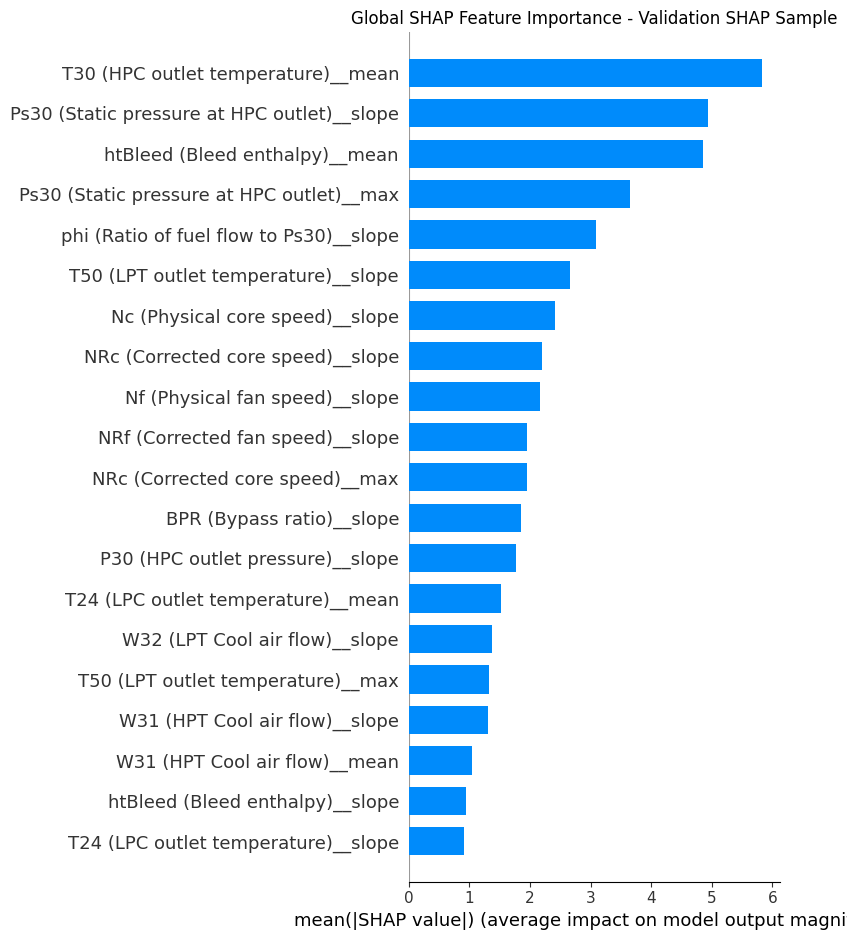

In [23]:
# SHAP bar plot aggregated over the validation SHAP sample.
shap.summary_plot(
    shap_values,
    X_val_shap,
    plot_type="bar",
    max_display=20,
    show=False,
)
plt.title("Global SHAP Feature Importance - Validation SHAP Sample")
plt.tight_layout()
plt.show()


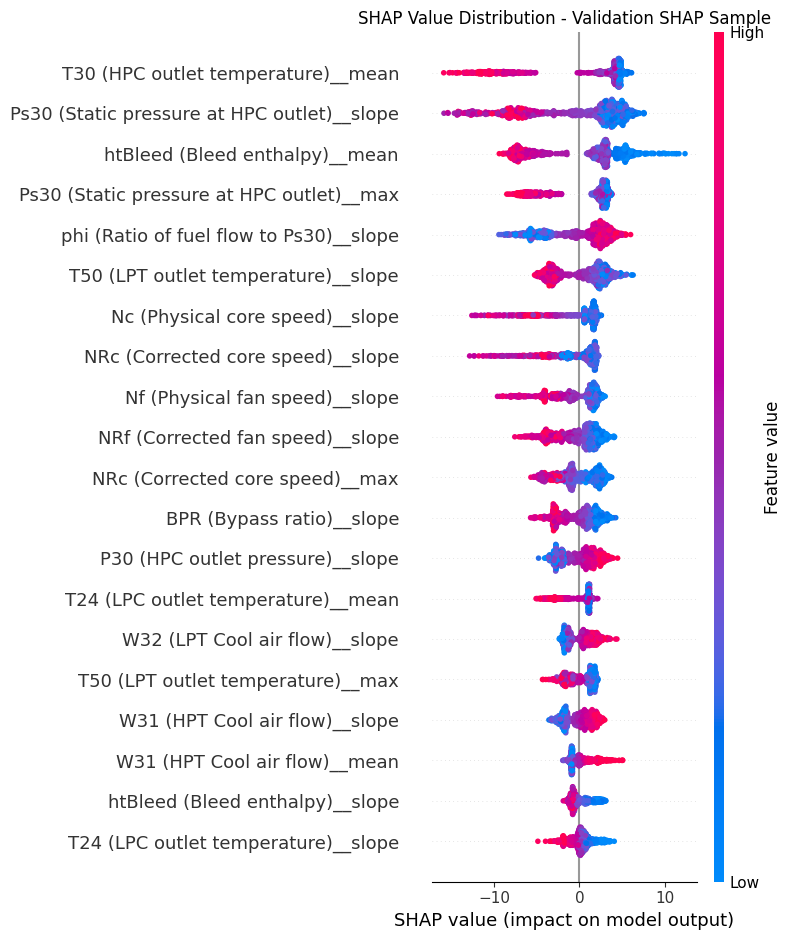

In [24]:
# SHAP beeswarm plot aggregated over the validation SHAP sample.
shap.summary_plot(
    shap_values,
    X_val_shap,
    max_display=20,
    show=False,
)
plt.title("SHAP Value Distribution - Validation SHAP Sample")
plt.tight_layout()
plt.show()


In [25]:
# aggregated sensor importance
sensor_shap_importance = (
    shap_importance
    .groupby("base_feature")["mean_abs_shap"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sensor_shap_importance.head(10)

,base_feature,mean_abs_shap
0,Ps30 (Static pressure at HPC outlet),9.104682
1,T30 (HPC outlet temperature),7.005528
2,htBleed (Bleed enthalpy),6.101162
3,NRc (Corrected core speed),4.992300
4,T50 (LPT outlet temperature),4.488520
5,Nc (Physical core speed),3.737959
6,phi (Ratio of fuel flow to Ps30),3.721872
7,Nf (Physical fan speed),3.398176
8,P30 (HPC outlet pressure),3.239495
9,T24 (LPC outlet temperature),3.167067


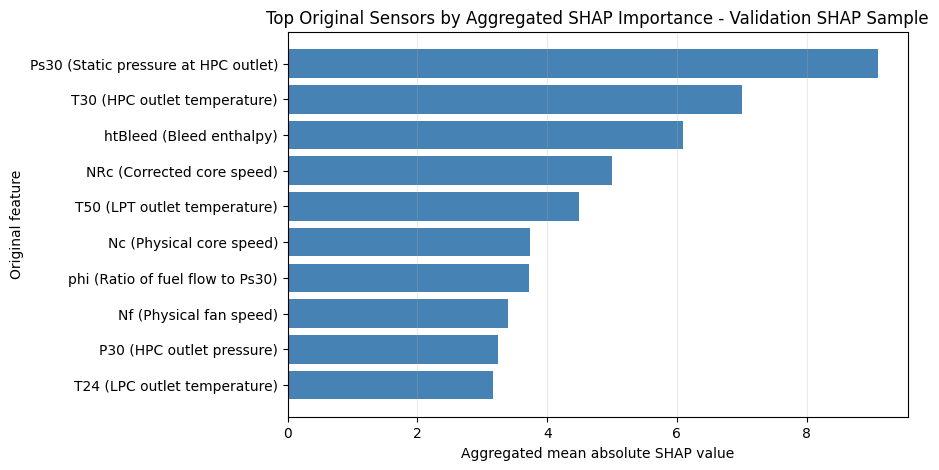

In [26]:
plt.figure(figsize=(8, 5))

plt.barh(
    sensor_shap_importance.head(10)["base_feature"][::-1],
    sensor_shap_importance.head(10)["mean_abs_shap"][::-1],
    color="steelblue"
)

plt.xlabel("Aggregated mean absolute SHAP value")
plt.ylabel("Original feature")
plt.title("Top Original Sensors by Aggregated SHAP Importance - Validation SHAP Sample")
plt.grid(axis="x", alpha=0.25)

plt.show()


In [27]:
# aggregated statistic importance
statistic_shap_importance = (
    shap_importance
    .groupby("statistic")["mean_abs_shap"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

statistic_shap_importance

,statistic,mean_abs_shap
0,slope,28.085552
1,mean,16.231808
2,max,11.113745
3,min,4.618284
4,std,2.726393
5,last,0.055284


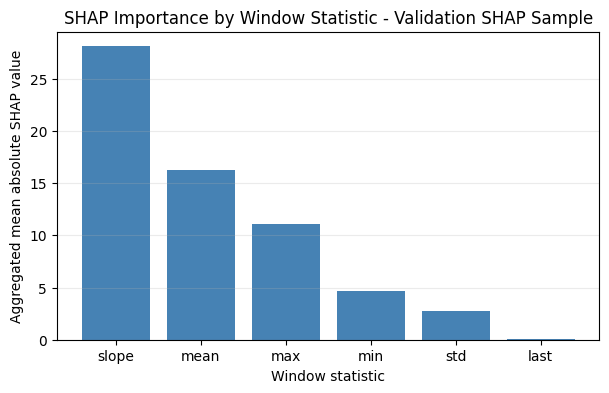

In [28]:
plt.figure(figsize=(7, 4))

plt.bar(
    statistic_shap_importance["statistic"],
    statistic_shap_importance["mean_abs_shap"],
    color="steelblue"
)

plt.xlabel("Window statistic")
plt.ylabel("Aggregated mean absolute SHAP value")
plt.title("SHAP Importance by Window Statistic - Validation SHAP Sample")
plt.grid(axis="y", alpha=0.25)

plt.show()


The global SHAP analysis identifies which engineered window features contribute most strongly to the XGBoost model's RUL predictions. Aggregating SHAP values by original sensor helps translate the engineered feature space back to sensor-level relevance, while aggregation by statistic shows whether the model relies more on current values, trends or distributional properties within each window.

# Local Prediction Explanations

Local SHAP explanations show how individual engineered features contribute to a single RUL prediction. This section keeps one representative waterfall plot as a reading example; the detailed early-, middle- and late-life local explanations are handled in the lifetime-point section below.


In [29]:
shap_sample_predictions = xgb_model.predict(X_val_shap)

local_explanation_df = val_shap_metadata.copy()
local_explanation_df["true_RUL"] = y_val_shap.values
local_explanation_df["predicted_RUL"] = shap_sample_predictions
local_explanation_df["prediction_error"] = (
    local_explanation_df["predicted_RUL"]
    - local_explanation_df["true_RUL"]
)

local_explanation_df.head()

,engine,start_cycle,end_cycle,true_RUL,predicted_RUL,prediction_error
0,5,133.0,162.0,107,100.124275,-6.875725
1,84,10.0,39.0,125,130.090775,5.090775
2,84,230.0,259.0,8,13.805676,5.805676
3,34,80.0,109.0,86,102.871811,16.871811
4,23,93.0,122.0,46,46.946133,0.946133


In [30]:
# Ensure that every SHAP sample has one corresponding prediction.
assert shap_sample_predictions.shape[0] == X_val_shap.shape[0]

# Ensure that local explanation metadata contains one row per SHAP sample.
assert local_explanation_df.shape[0] == X_val_shap.shape[0]

# Ensure that local predictions are finite numeric values.
assert np.isfinite(local_explanation_df["predicted_RUL"]).all()

In [31]:
# sample with low absolute error
sample_idx = (
    local_explanation_df["prediction_error"]
    .abs()
    .sort_values()
    .index[0]
)

local_explanation_df.loc[sample_idx]

engine               54.000000
start_cycle         210.000000
end_cycle           239.000000
true_RUL             18.000000
predicted_RUL        17.994894
prediction_error     -0.005106
Name: 678, dtype: float64

Representative local explanation from validation SHAP sample | engine: 54 | end cycle: 239 | true RUL: 18.0 | predicted RUL: 18.0


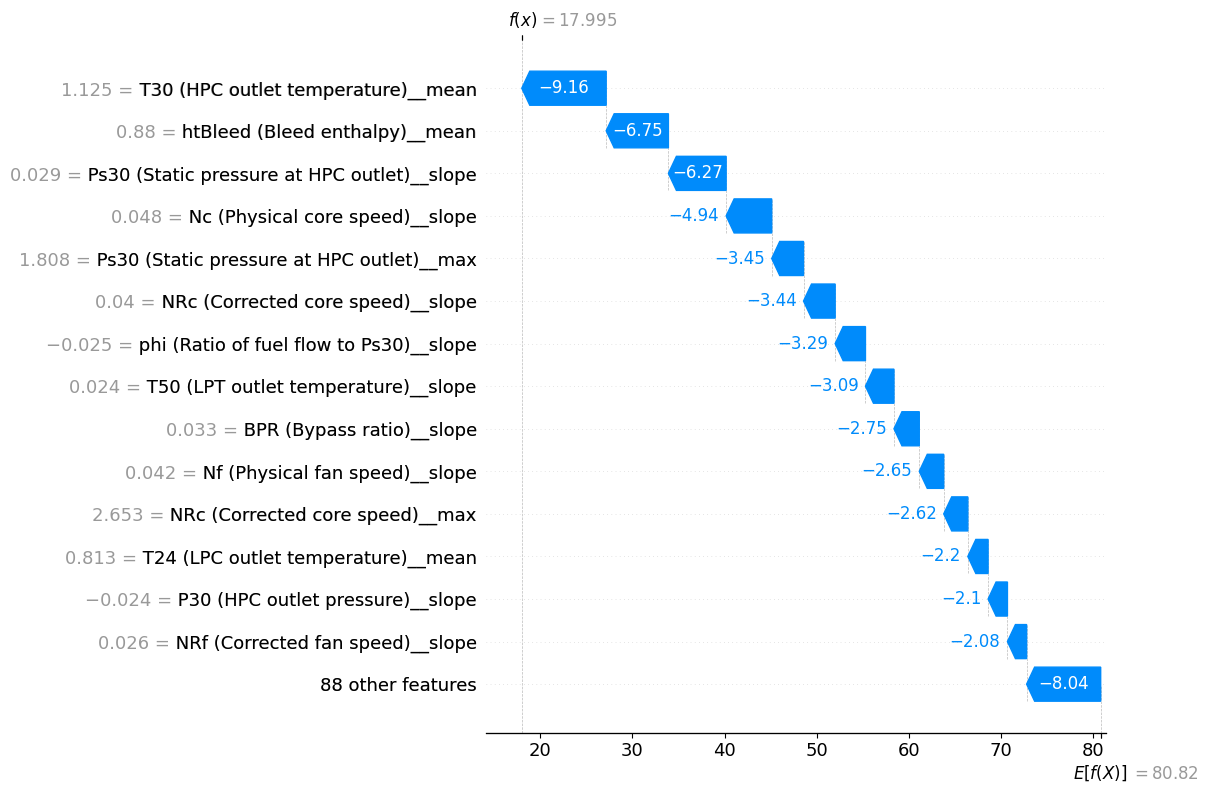

In [32]:
print(
    "Representative local explanation from validation SHAP sample | "
    f"engine: {int(local_explanation_df.loc[sample_idx, 'engine'])} | "
    f"end cycle: {int(local_explanation_df.loc[sample_idx, 'end_cycle'])} | "
    f"true RUL: {local_explanation_df.loc[sample_idx, 'true_RUL']:.1f} | "
    f"predicted RUL: {local_explanation_df.loc[sample_idx, 'predicted_RUL']:.1f}"
)

sample_explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_val_shap.iloc[sample_idx],
    feature_names=X_val_shap.columns
)

shap.plots.waterfall(
    sample_explanation,
    max_display=15
)


The local SHAP explanation decomposes one prediction into positive and negative feature contributions. Positive SHAP values increase the predicted RUL relative to the model's expected value, while negative SHAP values decrease it.

This single example introduces how a waterfall plot should be read. The more thesis-relevant comparison of local explanations across early, middle and late engine life is shown in the following lifetime-point section.


# Explanation Across Engine Lifetime

SHAP values can also be analyzed over time for a selected validation engine. This shows how feature contributions change across consecutive windows as the engine approaches failure.

In [33]:
# Count how many validation windows are available for each engine.
validation_engine_window_counts = (
    val_window_metadata
    .groupby("engine")
    .size()
    .sort_values(ascending=False)
)

validation_engine_window_counts.head()

engine
5     240
84    238
54    228
46    227
11    211
dtype: int64

In [34]:
# Select the validation engine with the largest number of windows.
selected_engine = validation_engine_window_counts.index[0]

selected_engine

np.int64(5)

In [35]:
# Select all window indices that belong to the chosen engine.
engine_window_indices = val_window_metadata[
    val_window_metadata["engine"] == selected_engine
].index

# Extract features, metadata and targets for the chosen engine.
X_engine = X_val_tabular.iloc[engine_window_indices].copy()
engine_metadata = val_window_metadata.iloc[engine_window_indices].copy()
y_engine = y_val_tabular.iloc[engine_window_indices].copy()

In [36]:
# Ensure that the selected engine has at least one validation window.
assert len(engine_window_indices) > 0

# Ensure that feature rows, metadata rows and target values are aligned for the selected engine.
assert X_engine.shape[0] == engine_metadata.shape[0] == y_engine.shape[0]

In [37]:
# Compute SHAP values for all windows of the selected engine.
engine_shap_values = explainer.shap_values(X_engine)

# Ensure that SHAP values are available for every selected engine window and feature.
assert engine_shap_values.shape == X_engine.shape

In [38]:
# Combine SHAP values, metadata, true RUL and predicted RUL in one dataframe.
engine_shap_df = pd.DataFrame(
    engine_shap_values,
    columns=X_engine.columns
)

engine_shap_df["engine"] = engine_metadata["engine"].values
engine_shap_df["start_cycle"] = engine_metadata["start_cycle"].values
engine_shap_df["end_cycle"] = engine_metadata["end_cycle"].values
engine_shap_df["true_RUL"] = y_engine.values
engine_shap_df["predicted_RUL"] = xgb_model.predict(X_engine)

engine_shap_df.head()

,setting_1__mean,setting_1__std,setting_1__min,setting_1__max,setting_1__last,setting_1__slope,setting_2__mean,setting_2__std,setting_2__min,setting_2__max,setting_2__last,setting_2__slope,T24 (LPC outlet temperature)__mean,T24 (LPC outlet temperature)__std,T24 (LPC outlet temperature)__min,T24 (LPC outlet temperature)__max,T24 (LPC outlet temperature)__last,T24 (LPC outlet temperature)__slope,T30 (HPC outlet temperature)__mean,T30 (HPC outlet temperature)__std,T30 (HPC outlet temperature)__min,T30 (HPC outlet temperature)__max,T30 (HPC outlet temperature)__last,T30 (HPC outlet temperature)__slope,T50 (LPT outlet temperature)__mean,T50 (LPT outlet temperature)__std,T50 (LPT outlet temperature)__min,T50 (LPT outlet temperature)__max,T50 (LPT outlet temperature)__last,T50 (LPT outlet temperature)__slope,P15 (bypass duct pressure)__mean,P15 (bypass duct pressure)__std,P15 (bypass duct pressure)__min,P15 (bypass duct pressure)__max,P15 (bypass duct pressure)__last,P15 (bypass duct pressure)__slope,P30 (HPC outlet pressure)__mean,P30 (HPC outlet pressure)__std,P30 (HPC outlet pressure)__min,P30 (HPC outlet pressure)__max,P30 (HPC outlet pressure)__last,P30 (HPC outlet pressure)__slope,Nf (Physical fan speed)__mean,Nf (Physical fan speed)__std,Nf (Physical fan speed)__min,Nf (Physical fan speed)__max,Nf (Physical fan speed)__last,Nf (Physical fan speed)__slope,Nc (Physical core speed)__mean,Nc (Physical core speed)__std,Nc (Physical core speed)__min,Nc (Physical core speed)__max,Nc (Physical core speed)__last,Nc (Physical core speed)__slope,Ps30 (Static pressure at HPC outlet)__mean,Ps30 (Static pressure at HPC outlet)__std,Ps30 (Static pressure at HPC outlet)__min,Ps30 (Static pressure at HPC outlet)__max,Ps30 (Static pressure at HPC outlet)__last,Ps30 (Static pressure at HPC outlet)__slope,phi (Ratio of fuel flow to Ps30)__mean,phi (Ratio of fuel flow to Ps30)__std,phi (Ratio of fuel flow to Ps30)__min,phi (Ratio of fuel flow to Ps30)__max,phi (Ratio of fuel flow to Ps30)__last,phi (Ratio of fuel flow to Ps30)__slope,NRf (Corrected fan speed)__mean,NRf (Corrected fan speed)__std,NRf (Corrected fan speed)__min,NRf (Corrected fan speed)__max,NRf (Corrected fan speed)__last,NRf (Corrected fan speed)__slope,NRc (Corrected core speed)__mean,NRc (Corrected core speed)__std,NRc (Corrected core speed)__min,NRc (Corrected core speed)__max,NRc (Corrected core speed)__last,NRc (Corrected core speed)__slope,BPR (Bypass ratio)__mean,BPR (Bypass ratio)__std,BPR (Bypass ratio)__min,BPR (Bypass ratio)__max,BPR (Bypass ratio)__last,BPR (Bypass ratio)__slope,htBleed (Bleed enthalpy)__mean,htBleed (Bleed enthalpy)__std,htBleed (Bleed enthalpy)__min,htBleed (Bleed enthalpy)__max,htBleed (Bleed enthalpy)__last,htBleed (Bleed enthalpy)__slope,W31 (HPT Cool air flow)__mean,W31 (HPT Cool air flow)__std,W31 (HPT Cool air flow)__min,W31 (HPT Cool air flow)__max,W31 (HPT Cool air flow)__last,W31 (HPT Cool air flow)__slope,W32 (LPT Cool air flow)__mean,W32 (LPT Cool air flow)__std,W32 (LPT Cool air flow)__min,W32 (LPT Cool air flow)__max,W32 (LPT Cool air flow)__last,W32 (LPT Cool air flow)__slope,engine,start_cycle,end_cycle,true_RUL,predicted_RUL
0,0.220047,-0.084753,-0.280714,0.268905,-0.000439,0.010376,-0.456337,-0.006557,0.021938,-0.275959,-0.000239,-0.000992,1.079856,0.079908,0.689687,0.252675,-0.039785,0.421580,4.770453,-0.066087,0.628284,0.119351,0.000969,0.458619,0.104431,0.190973,-0.407401,1.732767,-0.000705,-0.283258,0.034523,0.0,0.0,0.0,0.0,-0.020846,0.918053,0.238489,0.887308,1.158115,-0.001740,0.753425,0.411751,-0.670741,1.695812,0.283831,0.0,0.976100,0.000521,0.152862,0.188697,0.229406,0.010625,1.659172,1.125888,-0.012190,0.413478,3.270974,0.00066,3.375449,0.033644,0.177211,0.204986,0.405277,-0.000055,2.204359,0.662293,0.083914,0.000064,0.440340,0.000109,1.648454,-0.132180,0.570765,-0.068508,-0.853219,-0.000861,1.872720,0.266392,0.017633,0.922974,-0.425467,0.0074,1.619787,5.304409,-0.065496,0.185772,-0.033076,0.000118,1.608835,2.220613,0.06135

In [39]:
# Select the globally most important features for the time-dependent SHAP plot.
top_features = shap_importance.head(5)["feature"].tolist()

top_features

['T30 (HPC outlet temperature)__mean',
 'Ps30 (Static pressure at HPC outlet)__slope',
 'htBleed (Bleed enthalpy)__mean',
 'Ps30 (Static pressure at HPC outlet)__max',
 'phi (Ratio of fuel flow to Ps30)__slope']

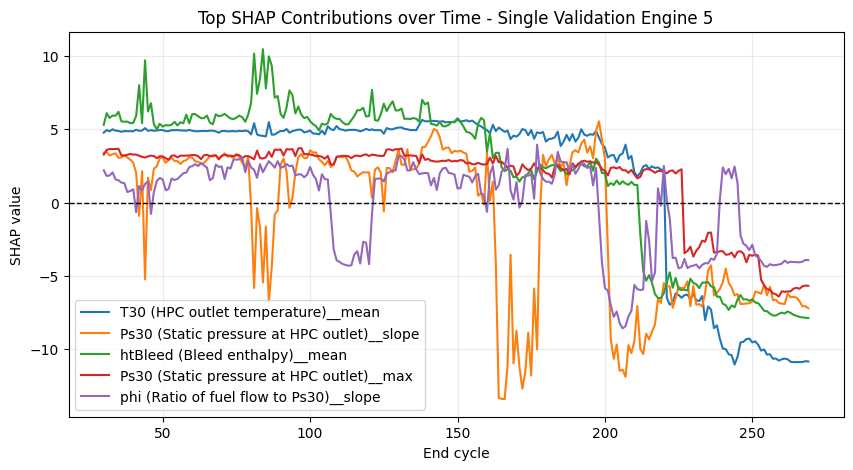

In [40]:
# Plot how the most important SHAP contributions change over the engine lifetime.
plt.figure(figsize=(10, 5))

for feature in top_features:
    plt.plot(
        engine_shap_df["end_cycle"],
        engine_shap_df[feature],
        label=feature
    )

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("End cycle")
plt.ylabel("SHAP value")
plt.title(f"Top SHAP Contributions over Time - Single Validation Engine {selected_engine}")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()


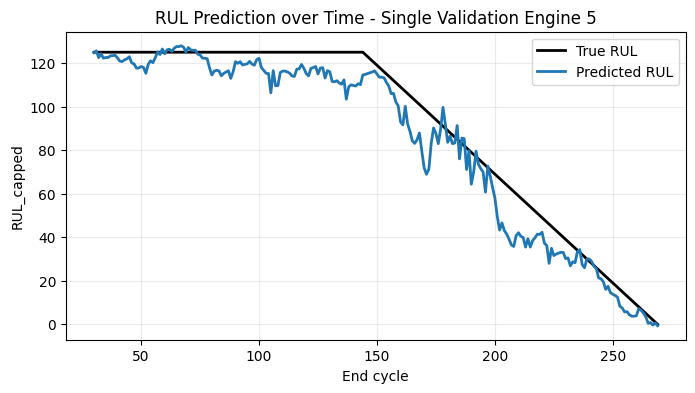

In [41]:
# Compare true and predicted RUL over time for the selected engine.
plt.figure(figsize=(8, 4))

plt.plot(
    engine_shap_df["end_cycle"],
    engine_shap_df["true_RUL"],
    label="True RUL",
    color="black",
    linewidth=2
)

plt.plot(
    engine_shap_df["end_cycle"],
    engine_shap_df["predicted_RUL"],
    label="Predicted RUL",
    color="tab:blue",
    linewidth=2
)

plt.xlabel("End cycle")
plt.ylabel("RUL_capped")
plt.title(f"RUL Prediction over Time - Single Validation Engine {selected_engine}")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()


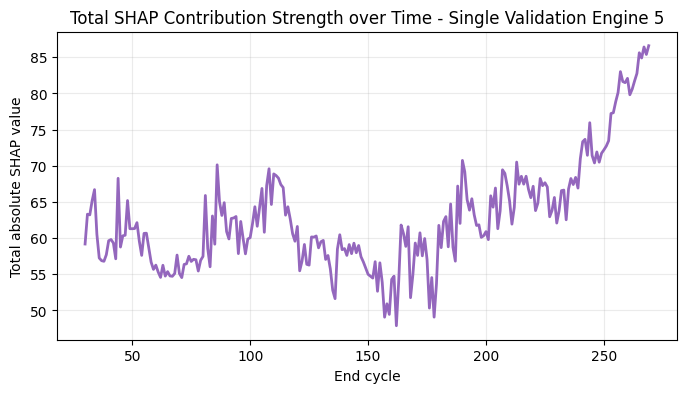

In [42]:
# Calculate the total absolute SHAP contribution strength per window.
engine_shap_df["total_abs_shap"] = np.abs(
    engine_shap_df[X_engine.columns]
).sum(axis=1)

# Plot how strongly the model relies on feature contributions over time.
plt.figure(figsize=(8, 4))

plt.plot(
    engine_shap_df["end_cycle"],
    engine_shap_df["total_abs_shap"],
    color="tab:purple",
    linewidth=2
)

plt.xlabel("End cycle")
plt.ylabel("Total absolute SHAP value")
plt.title(f"Total SHAP Contribution Strength over Time - Single Validation Engine {selected_engine}")
plt.grid(True, alpha=0.25)
plt.show()


# SHAP Explanations at Lifetime Points

To make the trajectory explanation more concrete, three windows from the selected validation engine are inspected: an early-life window, a mid-life window and a late-life window. Comparing these points shows whether the model uses the same sensor patterns throughout the trajectory or whether its reasoning shifts as the engine approaches failure.


In [43]:
# Select representative windows from early, middle and late engine lifetime.
lifetime_point_positions = {
    "early": 0.0,
    "middle": 0.5,
    "late": 1.0,
}

lifetime_point_rows = []
for lifetime_point, relative_position in lifetime_point_positions.items():
    point_index = int(round(relative_position * (len(engine_shap_df) - 1)))
    point_row = engine_shap_df.iloc[point_index]
    lifetime_point_rows.append({
        "lifetime_point": lifetime_point,
        "point_index": point_index,
        "engine": selected_engine,
        "end_cycle": point_row["end_cycle"],
        "true_RUL": point_row["true_RUL"],
        "predicted_RUL": point_row["predicted_RUL"],
    })

lifetime_points_df = pd.DataFrame(lifetime_point_rows)
lifetime_points_df


,lifetime_point,point_index,engine,end_cycle,true_RUL,predicted_RUL
0,early,0,5,30.0,125.0,124.779770
1,middle,120,5,150.0,119.0,114.992661
2,late,239,5,269.0,0.0,-0.648898


In [44]:
# Ensure that early, middle and late points can be represented by distinct windows.
assert len(engine_shap_df) >= 3

# Ensure that all selected lifetime points refer to valid windows from the selected engine.
assert lifetime_points_df["point_index"].between(0, len(engine_shap_df) - 1).all()
assert lifetime_points_df["engine"].eq(selected_engine).all()
assert lifetime_points_df["point_index"].is_unique
assert lifetime_points_df["end_cycle"].is_monotonic_increasing


In [45]:
# Create a long-format SHAP table for the selected lifetime points.
lifetime_point_shap_frames = []

for _, lifetime_row in lifetime_points_df.iterrows():
    point_index = int(lifetime_row["point_index"])
    point_shap = pd.DataFrame({
        "feature": X_engine.columns,
        "shap_value": engine_shap_values[point_index],
        "feature_value": X_engine.iloc[point_index].values,
    })
    point_shap["abs_shap"] = point_shap["shap_value"].abs()
    point_shap["base_feature"] = point_shap["feature"].str.split("__").str[0]
    point_shap["statistic"] = point_shap["feature"].str.split("__").str[1]
    point_shap["lifetime_point"] = lifetime_row["lifetime_point"]
    point_shap["end_cycle"] = lifetime_row["end_cycle"]
    point_shap["true_RUL"] = lifetime_row["true_RUL"]
    point_shap["predicted_RUL"] = lifetime_row["predicted_RUL"]
    lifetime_point_shap_frames.append(point_shap)

lifetime_point_shap_df = pd.concat(
    lifetime_point_shap_frames,
    ignore_index=True
)

lifetime_point_top_features = (
    lifetime_point_shap_df
    .sort_values(["lifetime_point", "abs_shap"], ascending=[True, False])
    .groupby("lifetime_point")
    .head(8)
    .reset_index(drop=True)
)

lifetime_point_top_features


,feature,shap_value,feature_value,abs_shap,base_feature,statistic,lifetime_point,end_cycle,true_RUL,predicted_RUL
0,htBleed (Bleed enthalpy)__mean,5.304409,-1.081330,5.304409,htBleed (Bleed enthalpy),mean,early,30.0,125.0,124.779770
1,T30 (HPC outlet temperature)__mean,4.770453,-1.241329,4.770453,T30 (HPC outlet temperature),mean,early,30.0,125.0,124.779770
2,Ps30 (Static pressure at HPC outlet)__slope,3.375449,-0.003399,3.375449,Ps30 (Static pressure at HPC outlet),slope,early,30.0,125.0,124.779770
3,Ps30 (Static pressure at HPC outlet)__max,3.270974,-0.751418,3.270974,Ps30 (Static pressure at HPC outlet),max,early,30.0,125.0,124.779770
4,W31 (HPT Cool air flow)__mean,2.220613,1.271715,2.220613,W31 (HPT Cool air flow),mean,early,30.0,125.0,124.779770
5,phi (Ratio of fuel flow to Ps30)__slope,2.204359,0.003532,2.204359,phi (Ratio of fuel flow to Ps30),slope,early,30.0,125.0,124.779770
6,NRc (Corrected core speed)__slope,1.872720,0.000896,1.872720,NRc (Corrected core speed),slope,early,30.0,125.0,124.779770
7,T50 (LPT outlet temperature)__max,1.732767,-0.719336,1.732767,T50 (LPT outlet temperature),max,early,30.0,125.0,124.779770
8,T30 (HPC outlet temperature)__mean,-10.843879,1.660290,10.843879,T30 (HPC outlet temperature),mean,late,269.0,0.0,-0.648898
9,htBleed (Bleed enthalpy)__mean,-7.882277,1.699555,7.882277,htBleed (Bleed enthalpy),mean,late,269.0,0.0,-0.648898


In [46]:
# Verify that the selected-point SHAP table covers all engineered features for every point.
assert lifetime_point_shap_df.shape[0] == len(lifetime_points_df) * X_engine.shape[1]
assert set(lifetime_point_shap_df["lifetime_point"]) == set(lifetime_point_positions)
assert np.isfinite(lifetime_point_shap_df["shap_value"]).all()


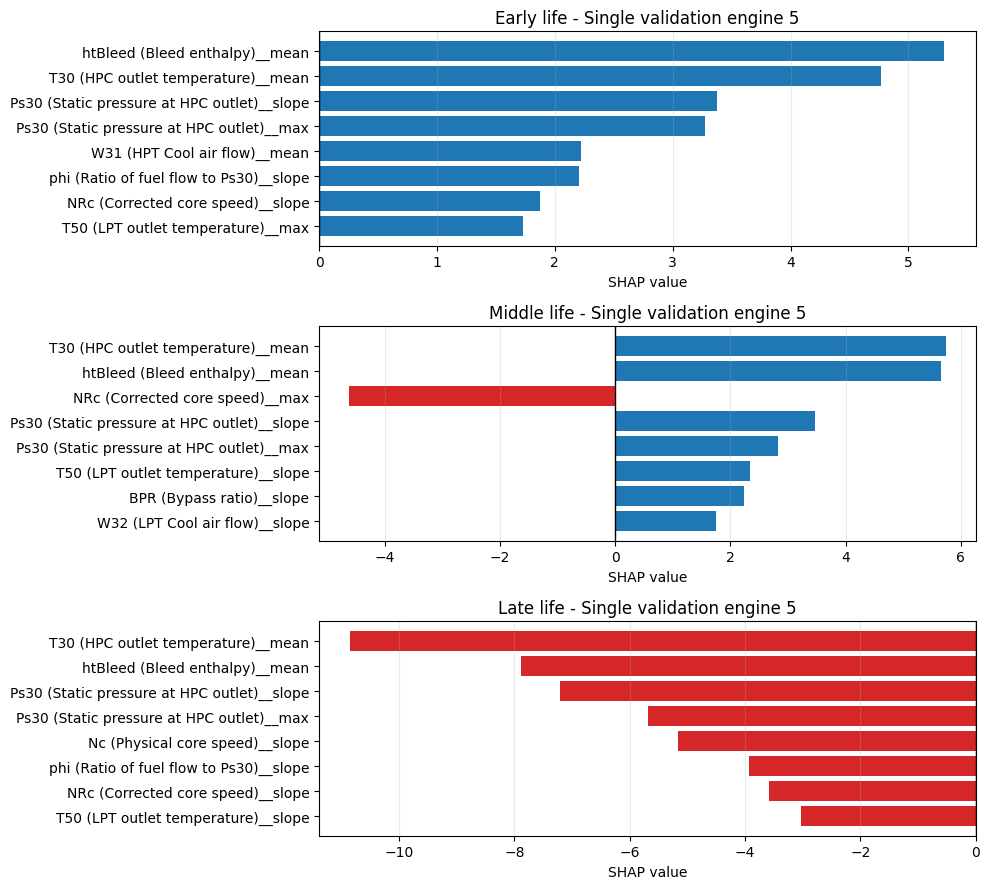

In [47]:
# Plot the strongest local SHAP contributions at each lifetime point.
fig, axes = plt.subplots(
    nrows=len(lifetime_point_positions),
    ncols=1,
    figsize=(10, 9),
    sharex=False
)

for ax, lifetime_point in zip(axes, lifetime_point_positions):
    point_features = lifetime_point_top_features[
        lifetime_point_top_features["lifetime_point"] == lifetime_point
    ].sort_values("abs_shap", ascending=True)

    colors = np.where(
        point_features["shap_value"] >= 0,
        "tab:blue",
        "tab:red"
    )

    ax.barh(
        point_features["feature"],
        point_features["shap_value"],
        color=colors
    )
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"{lifetime_point.title()} life - Single validation engine {selected_engine}")
    ax.set_xlabel("SHAP value")
    ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()


Single validation engine 5 | Early life | end cycle: 30 | true RUL: 125.0 | predicted RUL: 124.8


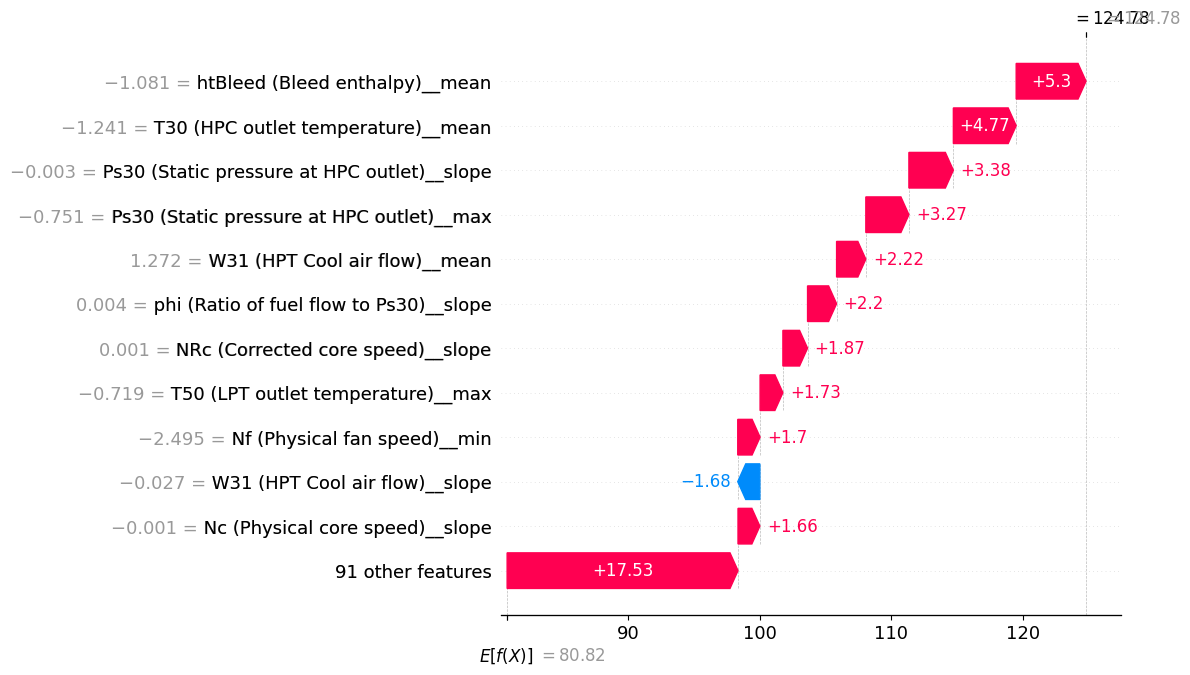

Single validation engine 5 | Middle life | end cycle: 150 | true RUL: 119.0 | predicted RUL: 115.0


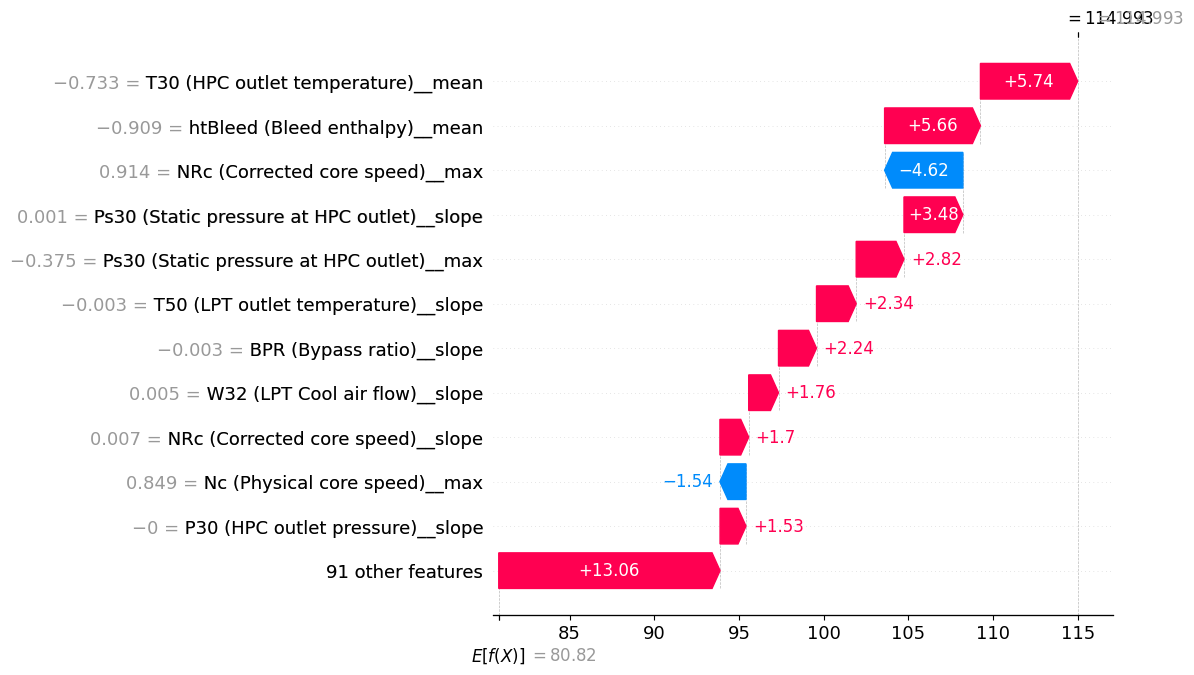

Single validation engine 5 | Late life | end cycle: 269 | true RUL: 0.0 | predicted RUL: -0.6


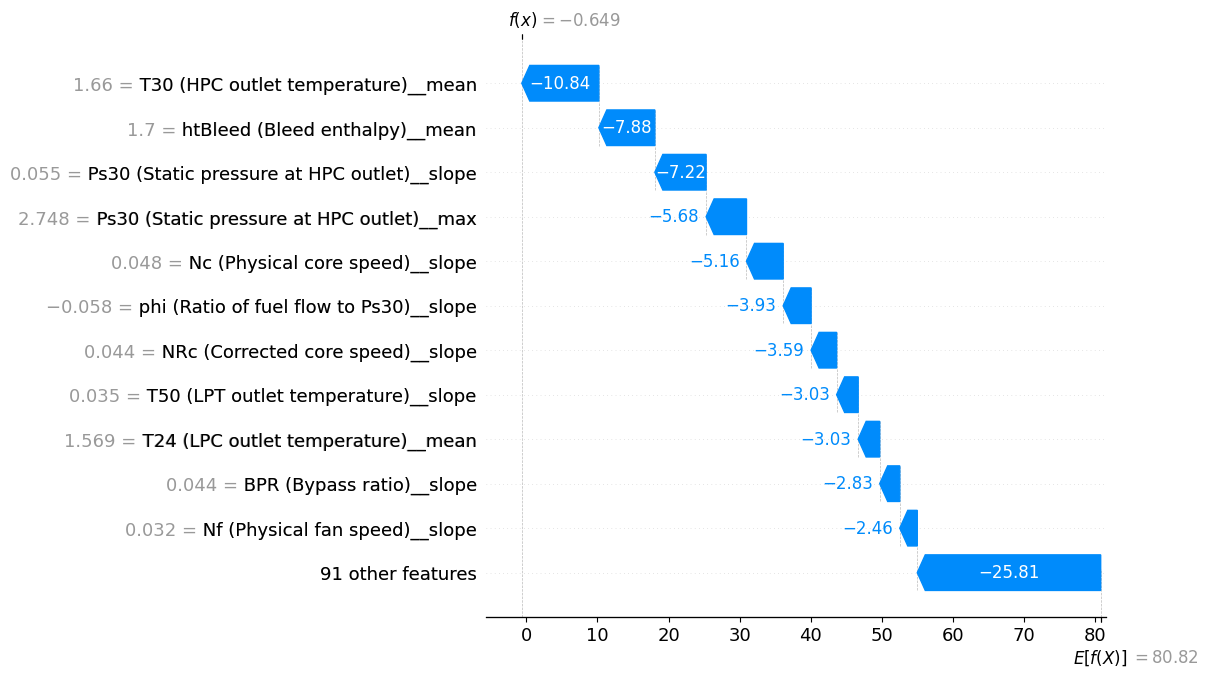

In [48]:
# Show detailed waterfall explanations for each selected lifetime point.
for _, lifetime_row in lifetime_points_df.iterrows():
    point_index = int(lifetime_row["point_index"])
    lifetime_point = lifetime_row["lifetime_point"]

    print(
        f"Single validation engine {selected_engine} | {lifetime_point.title()} life | "
        f"end cycle: {int(lifetime_row['end_cycle'])} | "
        f"true RUL: {lifetime_row['true_RUL']:.1f} | "
        f"predicted RUL: {lifetime_row['predicted_RUL']:.1f}"
    )

    point_explanation = shap.Explanation(
        values=engine_shap_values[point_index],
        base_values=explainer.expected_value,
        data=X_engine.iloc[point_index],
        feature_names=X_engine.columns
    )

    shap.plots.waterfall(
        point_explanation,
        max_display=12
    )


In [49]:
# Aggregate local SHAP strength by original sensor or setting for the selected lifetime points.
lifetime_sensor_importance = (
    lifetime_point_shap_df
    .groupby(["lifetime_point", "base_feature"])["abs_shap"]
    .sum()
    .reset_index()
)

top_lifetime_sensors = (
    lifetime_sensor_importance
    .groupby("base_feature")["abs_shap"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
)

lifetime_sensor_pivot = (
    lifetime_sensor_importance[
        lifetime_sensor_importance["base_feature"].isin(top_lifetime_sensors)
    ]
    .pivot_table(
        index="base_feature",
        columns="lifetime_point",
        values="abs_shap",
        fill_value=0
    )
    .reindex(columns=list(lifetime_point_positions))
    .loc[top_lifetime_sensors]
)

lifetime_sensor_pivot


lifetime_point,early,middle,late
base_feature,,,
Ps30 (Static pressure at HPC outlet),8.198640,6.427755,13.495743
T30 (HPC outlet temperature),6.043763,6.300551,12.482094
htBleed (Bleed enthalpy),7.197706,6.855309,8.940104
NRc (Corrected core speed),3.498252,7.615726,6.902532
T50 (LPT outlet temperature),2.719535,4.386954,5.677095
Nc (Physical core speed),2.241282,2.694840,7.329510
BPR (Bypass ratio),3.259652,4.461549,4.329542
P30 (HPC outlet pressure),3.957130,2.991510,3.411252


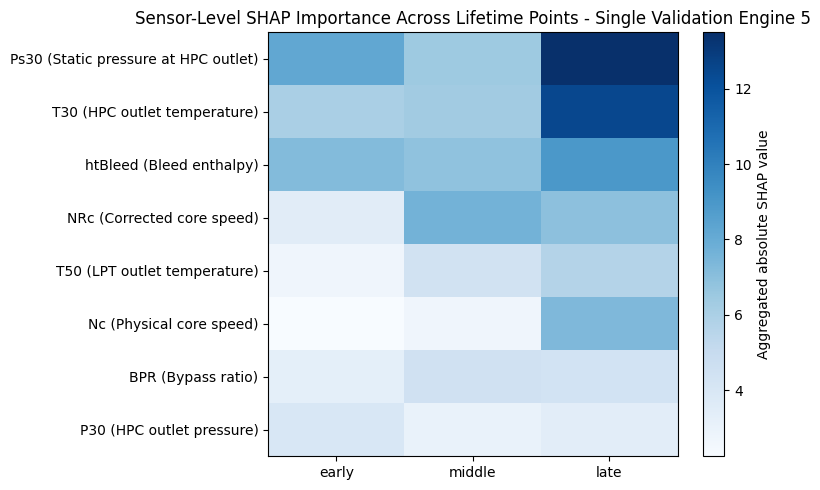

In [50]:
# Visualize how sensor-level SHAP importance shifts across lifetime points.
plt.figure(figsize=(8, 5))

plt.imshow(
    lifetime_sensor_pivot,
    aspect="auto",
    cmap="Blues"
)

plt.xticks(
    ticks=np.arange(len(lifetime_sensor_pivot.columns)),
    labels=lifetime_sensor_pivot.columns
)

plt.yticks(
    ticks=np.arange(len(lifetime_sensor_pivot.index)),
    labels=lifetime_sensor_pivot.index
)

plt.colorbar(label="Aggregated absolute SHAP value")
plt.title(f"Sensor-Level SHAP Importance Across Lifetime Points - Single Validation Engine {selected_engine}")
plt.tight_layout()
plt.show()


In [51]:
# Aggregate local SHAP strength by window statistic for the selected lifetime points.
lifetime_statistic_importance = (
    lifetime_point_shap_df
    .groupby(["lifetime_point", "statistic"])["abs_shap"]
    .sum()
    .reset_index()
)

lifetime_statistic_pivot = (
    lifetime_statistic_importance
    .pivot_table(
        index="statistic",
        columns="lifetime_point",
        values="abs_shap",
        fill_value=0
    )
    .reindex(columns=list(lifetime_point_positions))
)

lifetime_statistic_pivot


lifetime_point,early,middle,late
statistic,,,
last,0.220253,0.049177,0.054149
max,11.196922,13.298291,13.533818
mean,18.080820,16.433306,27.713152
min,7.004257,4.731962,3.663015
slope,20.176674,18.366655,38.172989
std,2.501052,2.112378,3.459137


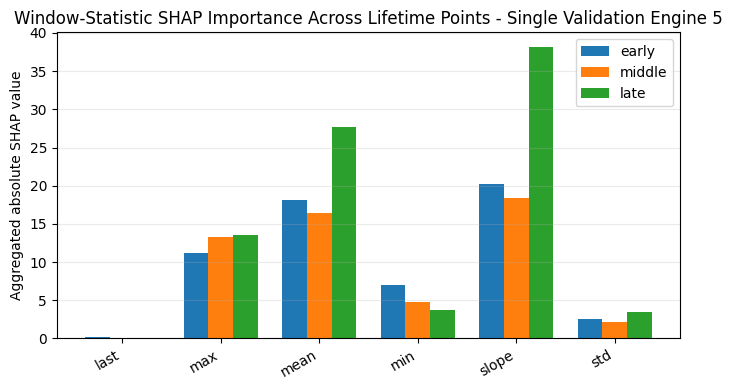

In [52]:
# Visualize how the model shifts between recent values, averages, variability and trends.
plt.figure(figsize=(7, 4))

x = np.arange(len(lifetime_statistic_pivot.index))
bar_width = 0.25

for offset, lifetime_point in enumerate(lifetime_statistic_pivot.columns):
    plt.bar(
        x + (offset - 1) * bar_width,
        lifetime_statistic_pivot[lifetime_point],
        width=bar_width,
        label=lifetime_point
    )

plt.xticks(
    ticks=x,
    labels=lifetime_statistic_pivot.index,
    rotation=30,
    ha="right"
)
plt.ylabel("Aggregated absolute SHAP value")
plt.title(f"Window-Statistic SHAP Importance Across Lifetime Points - Single Validation Engine {selected_engine}")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


The lifetime-point explanations make the temporal interpretation more concrete. The early point shows which features keep the prediction near a high RUL estimate, the middle point shows the transition region, and the late point shows which features contribute to a lower predicted RUL near the end of the trajectory.

Comparing local explanations across these points helps identify whether the model relies on stable sensor patterns throughout the lifecycle or whether different sensors and window statistics become more influential as degradation progresses. Positive SHAP values increase the predicted RUL, while negative SHAP values push the prediction toward earlier failure.


The trajectory-level SHAP analysis shows how the model's feature contributions evolve over consecutive windows of the same engine. This is useful for predictive maintenance because decisions are made over time as new sensor windows become available.

Changes in SHAP contributions near the end of an engine's lifetime can indicate which engineered features the model uses as evidence for decreasing RUL. However, these explanations describe model behavior and should not be interpreted as direct physical causality.

# Interpretation of Engineered Features

The model was trained on engineered window features. To make SHAP results easier to interpret, feature importance is aggregated by original sensor and by statistical descriptor.

In [53]:
# Show the most important engineered features based on mean absolute SHAP values.
top_engineered_features = shap_importance.head(20)

top_engineered_features

,feature,mean_abs_shap,base_feature,statistic
0,T30 (HPC outlet temperature)__mean,5.834907,T30 (HPC outlet temperature),mean
1,Ps30 (Static pressure at HPC outlet)__slope,4.936744,Ps30 (Static pressure at HPC outlet),slope
2,htBleed (Bleed enthalpy)__mean,4.860750,htBleed (Bleed enthalpy),mean
3,Ps30 (Static pressure at HPC outlet)__max,3.648803,Ps30 (Static pressure at HPC outlet),max
4,phi (Ratio of fuel flow to Ps30)__slope,3.088325,phi (Ratio of fuel flow to Ps30),slope
5,T50 (LPT outlet temperature)__slope,2.667413,T50 (LPT outlet temperature),slope
6,Nc (Physical core speed)__slope,2.406237,Nc (Physical core speed),slope
7,NRc (Corrected core speed)__slope,2.193835,NRc (Corrected core speed),slope
8,Nf (Physical fan speed)__slope,2.170959,Nf (Physical fan speed),slope
9,NRf (Corrected fan speed)__slope,1.959607,NRf (Corrected fan speed),slope


In [54]:
# Aggregate SHAP importance by original sensor or operational setting.
sensor_shap_importance = (
    shap_importance
    .groupby("base_feature")["mean_abs_shap"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sensor_shap_importance.head(10)

,base_feature,mean_abs_shap
0,Ps30 (Static pressure at HPC outlet),9.104682
1,T30 (HPC outlet temperature),7.005528
2,htBleed (Bleed enthalpy),6.101162
3,NRc (Corrected core speed),4.992300
4,T50 (LPT outlet temperature),4.488520
5,Nc (Physical core speed),3.737959
6,phi (Ratio of fuel flow to Ps30),3.721872
7,Nf (Physical fan speed),3.398176
8,P30 (HPC outlet pressure),3.239495
9,T24 (LPC outlet temperature),3.167067


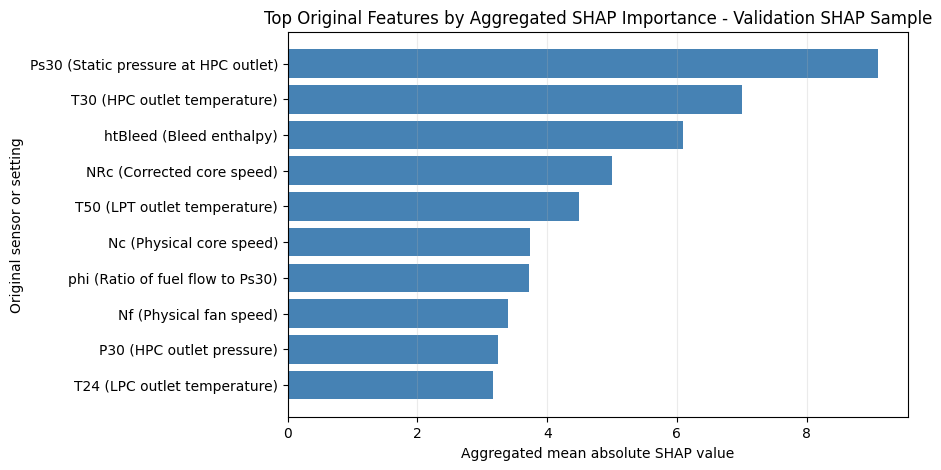

In [55]:
# Plot the most important original sensors/settings after SHAP aggregation.
plt.figure(figsize=(8, 5))

plt.barh(
    sensor_shap_importance.head(10)["base_feature"][::-1],
    sensor_shap_importance.head(10)["mean_abs_shap"][::-1],
    color="steelblue"
)

plt.xlabel("Aggregated mean absolute SHAP value")
plt.ylabel("Original sensor or setting")
plt.title("Top Original Features by Aggregated SHAP Importance - Validation SHAP Sample")
plt.grid(axis="x", alpha=0.25)

plt.show()


In [56]:
# Aggregate SHAP importance by statistical window descriptor.
statistic_shap_importance = (
    shap_importance
    .groupby("statistic")["mean_abs_shap"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

statistic_shap_importance

,statistic,mean_abs_shap
0,slope,28.085552
1,mean,16.231808
2,max,11.113745
3,min,4.618284
4,std,2.726393
5,last,0.055284


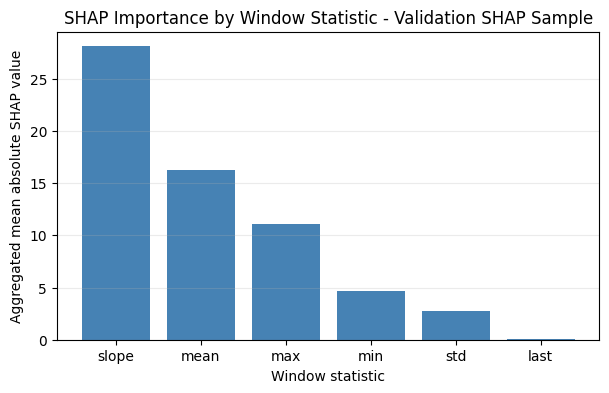

In [57]:
# Plot which statistical descriptors are most influential.
plt.figure(figsize=(7, 4))

plt.bar(
    statistic_shap_importance["statistic"],
    statistic_shap_importance["mean_abs_shap"],
    color="steelblue"
)

plt.xlabel("Window statistic")
plt.ylabel("Aggregated mean absolute SHAP value")
plt.title("SHAP Importance by Window Statistic - Validation SHAP Sample")
plt.grid(axis="y", alpha=0.25)

plt.show()


In [58]:
# Create a sensor-statistic importance matrix.
sensor_statistic_importance = (
    shap_importance
    .pivot_table(
        index="base_feature",
        columns="statistic",
        values="mean_abs_shap",
        aggfunc="sum",
        fill_value=0
    )
)

sensor_statistic_importance["total_importance"] = sensor_statistic_importance.sum(axis=1)

sensor_statistic_importance = sensor_statistic_importance.sort_values(
    "total_importance",
    ascending=False
)

sensor_statistic_importance.head(10)

statistic,last,max,mean,min,slope,std,total_importance
base_feature,,,,,,,
Ps30 (Static pressure at HPC outlet),0.000590,3.648803,0.213868,0.264763,4.936744,0.039915,9.104682
T30 (HPC outlet temperature),0.001403,0.447641,5.834907,0.214425,0.410849,0.096304,7.005529
htBleed (Bleed enthalpy),0.000261,0.025138,4.860750,0.122797,0.950298,0.141918,6.101163
NRc (Corrected core speed),0.023369,1.951911,0.230521,0.217327,2.193835,0.375337,4.992300
T50 (LPT outlet temperature),0.001171,1.331269,0.098451,0.284002,2.667413,0.106215,4.488520
Nc (Physical core speed),0.012588,0.531446,0.058798,0.218174,2.406237,0.510717,3.737959
phi (Ratio of fuel flow to Ps30),0.000101,0.170184,0.111897,0.157742,3.088325,0.193624,3.721872
Nf (Physical fan speed),0.000000,0.188014,0.147977,0.394510,2.170959,0.496716,3.398176
P30 (HPC outlet pressure),0.000088,0.176919,0.340113,0.796525,1.776688,0.149162,3.239495


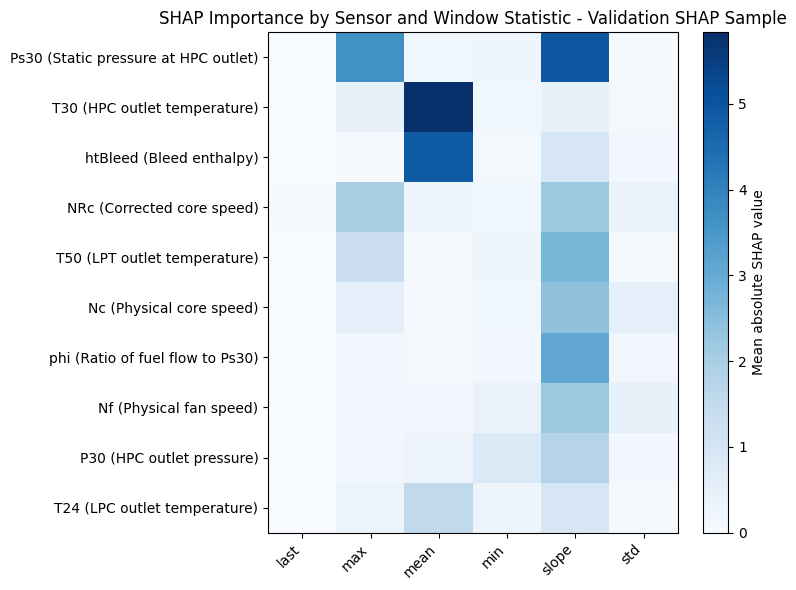

In [59]:
# Visualize SHAP importance across sensors and window statistics.
top_sensor_statistic_importance = (
    sensor_statistic_importance
    .drop(columns="total_importance")
    .head(10)
)

plt.figure(figsize=(8, 6))

plt.imshow(
    top_sensor_statistic_importance,
    aspect="auto",
    cmap="Blues"
)

plt.xticks(
    ticks=np.arange(len(top_sensor_statistic_importance.columns)),
    labels=top_sensor_statistic_importance.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(top_sensor_statistic_importance.index)),
    labels=top_sensor_statistic_importance.index
)

plt.colorbar(label="Mean absolute SHAP value")
plt.title("SHAP Importance by Sensor and Window Statistic - Validation SHAP Sample")
plt.tight_layout()
plt.show()


In [60]:
# Ensure that aggregated sensor importance accounts for all engineered feature importance.
assert np.isclose(
    sensor_shap_importance["mean_abs_shap"].sum(),
    shap_importance["mean_abs_shap"].sum()
)

# Ensure that aggregated statistic importance accounts for all engineered feature importance.
assert np.isclose(
    statistic_shap_importance["mean_abs_shap"].sum(),
    shap_importance["mean_abs_shap"].sum()
)

Aggregating SHAP values by original sensor translates the engineered feature space back into domain-level signals. This helps identify which sensors the model relies on most strongly for RUL prediction.

Aggregating by window statistic shows whether the model primarily uses recent values, average behavior, variability or trend information within each window.

The sensor-statistic matrix combines both perspectives and highlights which types of temporal summaries are most relevant for each sensor.


# Explainability Takeaways

The SHAP analysis provides insight into how the XGBoost model uses engineered window features to predict capped RUL.

Global SHAP importance identifies the engineered features with the strongest overall influence on model predictions. These features combine original sensor signals with statistical window descriptors such as mean, last value, variability or trend.

Aggregating SHAP values by original sensor makes the explanations easier to interpret at the sensor level. This helps identify which sensor signals the model relies on most strongly for RUL prediction.

Aggregating SHAP values by window statistic shows whether the model depends more on recent values, average behavior, variability or trend information within the sliding windows.

Local explanations show how individual predictions are formed from positive and negative feature contributions relative to the model's expected prediction.

Trajectory-level explanations show how feature contributions evolve across consecutive windows of the same engine. The added early-, middle- and late-life explanations make this shift explicit by comparing concrete points in one machine's lifetime.

The SHAP results explain the behavior of the trained model, not the physical causal mechanisms of engine degradation. Therefore, the identified important features should be interpreted as model-relevant signals rather than direct physical causes.

The next step is to connect RUL predictions with maintenance decision-making, for example through a simple maintenance scheduling or cost simulation.
